In [1]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [2]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'chain_fixed_interventions'
program = 'chain'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'pareto_fitness.txt')
files = glob(pattern, recursive=True)

records = []
for fp in files:
    df = pd.read_csv(fp, sep='\t', header=None, names=['generation', 'fitness_class'])
    df[['fitness', 'class']] = pd.DataFrame(
        df['fitness_class'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        ).tolist(),
        index=df.index,
    )
    df['run'] = path.basename(path.dirname(fp))
    records.append(df[['generation', 'fitness', 'class', 'run']])

if records:
    pareto_fitness = pd.concat(records, ignore_index=True)
else:
    pareto_fitness = pd.DataFrame(columns=['generation', 'fitness', 'class', 'run'])

# Aggregate mean/std per generation and class
pareto_stats = (
    pareto_fitness
    .groupby(['generation', 'class'])['fitness']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'fitness_mean', 'std': 'fitness_std', 'count': 'n'})
)
pareto_stats['fitness_std'] = pareto_stats['fitness_std'].fillna(0)

print(f"Found {len(files)} pareto_fitness.txt files")
print(pareto_stats.head())
print(f"\nGenerations: {pareto_stats['generation'].min() if not pareto_stats.empty else 'NA'} to {pareto_stats['generation'].max() if not pareto_stats.empty else 'NA'}")

# Save aggregated stats to a new file csv named ex_name + '_pareto_stats.csv' and
# saved in ../results/synhesis
output_fp = path.join('..', 'results', 'synthesis', f'{ex_name}_pareto_stats.csv')
pareto_stats.to_csv(output_fp, index=False)

Found 6 pareto_fitness.txt files
   generation  class  fitness_mean  fitness_std  n
0           0     -3   -169.098833     0.000000  1
1           0     -2   -174.788894    16.035993  3
2           0     -1  -1029.246985  1558.333765  4
3           0      0   -268.741284     0.239205  2
4           1     -3   -169.098833     0.000000  1

Generations: 0 to 300


In [3]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood += interventional_likelihood
    likelihood_base += interventional_likelihood_base


print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Total likelihood of real program: -56.59039294844115
Total likelihood of baseline program: -100.3560523609337


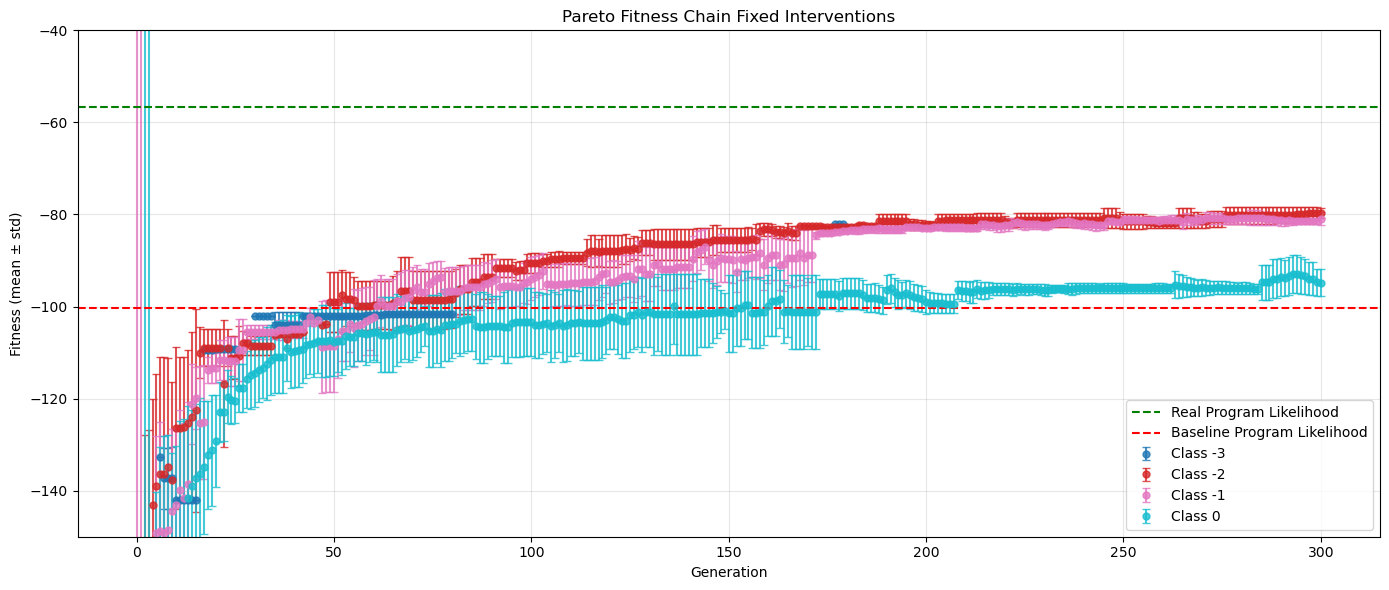

In [4]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_mean'],
            yerr=cls_df['fitness_std'],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-150, -40])
    #add horizontal line for likelihood of real program
    ax.axhline(y=likelihood, color='g', linestyle='--', label='Real Program Likelihood')
    ax.axhline(y=likelihood_base, color='r', linestyle='--', label='Baseline Program Likelihood')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [5]:
# find the folder that contains the best fitnes and in that folder open the folder first_front which contains files like 0.txt, 1.txt... and find the file
# that contains in the last row [best fitness, n] the best fitness and print the content of that file
# ...existing code...
# find the run folder that contains the best fitness, open its first_front/*.txt files,
# check the last non-empty row for [best_fitness, n] and print the matching file content
import math
from glob import glob

if pareto_fitness.empty:
    print("No pareto_fitness data available.")
else:
    best_idx = pareto_fitness['fitness'].idxmax()
    best_fitness = float(pareto_fitness.loc[best_idx, 'fitness'])
    best_runs = pareto_fitness[pareto_fitness['fitness'] == best_fitness]['run'].unique().tolist()
    print(f"Best fitness = {best_fitness}, candidate runs: {best_runs}")

    found = False
    for run in best_runs:
        run_dir = path.join(base_dir, run)
        ff_dirs = glob(path.join(run_dir, "**", "first_front"), recursive=True)
        for ff in ff_dirs:
            txt_files = sorted(glob(path.join(ff, "*.txt")))
            for txt_path in txt_files:
                with open(txt_path, "r") as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 1:
                    try:
                        val = float(last_row[0])
                    except Exception:
                        continue
                    if math.isclose(val, best_fitness, rel_tol=1e-9, abs_tol=1e-6):
                        print(f"Found matching file: {txt_path}")
                        print("---- file content ----")
                        print("\n".join(lines))
                        print("----------------------")
                        found = True
                        # Save the matching file content to a new file in ../results/synthesis
                        output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front.txt')
                        with open(output_file, 'w') as out_f:
                            out_f.write("\n".join(lines))
                        break
            if found:
                break
        if found:
            break

    if not found:
        print("No first_front/*.txt file found whose last row matches the best fitness.")
# ...existing code...

Best fitness = -77.86085764018694, candidate runs: ['e243-012.eduroam.tuwien.ac.at_26_1_14_111738_955925_17271_0']
Found matching file: ../results/chain_fixed_interventions/e243-012.eduroam.tuwien.ac.at_26_1_14_111738_955925_17271_0/first_front/1.txt
---- file content ----
Generation:
300
Phenotype:
1
V1 = gm([1.1, 49.6, 43.9], [48.5, 9, 1], [48, 12, 3]);
V2 = V1 - V1;
V2 = V2 + gm([35.2, 50.5, 2.2]) - uniform([22, 29.1], 3);
V3 = V2 * V2;
V3 = V3 + uniform([0, 3], 2) - gm([23, 2, 3.6], [14.9, 22, 26]);
Pre-processed Program
:F = gm([0.011270, 0.496926, 0.491803], [49.6, 9, 12], [43.9, 1, 3]);T = F;T = T - F;T = T;T = T + gm([1.000000], [50.5], [2.2]);T = T - uniform([22.000000, 51.100000], 3);TEMP0 = T * T;P = TEMP0;P = P;P = P + uniform([0.000000, 3.000000], 2);P = P - gm([0.606860, 0.393140], [2, 22], [3.6, 26]);Genotype:
[226, 48, 230, 116, 285, 470, 33, 441, 125, 409, 315, 331, 457, 410, 345, 196, 35, 365, 147, 99, 157, 172, 366, 488, 154, 442, 414, 150, 430, 114, 358, 309, 222, 2

In [6]:
# find the best file per complexity (n) in the last evolution step across all runs
import os
import re
import ast
from glob import glob

def _extract_gen_num(p: str):
    parts = p.split(os.sep)
    for part in reversed(parts):
        m = re.search(r'(?:gen|generation)[_-]?(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
        m = re.fullmatch(r'g(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
    return None

def _coerce_num(val):
    try:
        num = float(val)
    except Exception:
        return None
    if abs(num - round(num)) < 1e-9:
        return int(round(num))
    return num

if pareto_fitness.empty:
    print('No pareto_fitness data available.')
else:
    max_gen = pareto_fitness['generation'].max()
    if max_gen is not None:
        max_gen = int(max_gen)

    ff_dirs = glob(path.join(base_dir, '**', 'first_front'), recursive=True)
    if not ff_dirs:
        print('No first_front directory found under base_dir.')
    else:
        if max_gen is not None:
            filtered = [d for d in ff_dirs if _extract_gen_num(d) == max_gen]
        else:
            filtered = []
        if filtered:
            ff_dirs = filtered

        best_by_n = {}
        for ff_dir in ff_dirs:
            txt_files = sorted(glob(path.join(ff_dir, '*.txt')))
            for txt_path in txt_files:
                with open(txt_path, 'r') as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 2:
                    fitness = _coerce_num(last_row[0])
                    n_val = _coerce_num(last_row[1])
                    if fitness is None or n_val is None:
                        continue
                    current = best_by_n.get(n_val)
                    if current is None or fitness > current['fitness']:
                        best_by_n[n_val] = {
                            'fitness': fitness,
                            'path': txt_path,
                            'lines': lines,
                        }

        if not best_by_n:
            print('No valid first_front/*.txt files found for the last evolution step.')
        else:
            for n_val in sorted(best_by_n.keys()):
                entry = best_by_n[n_val]
                print(f'Best for n={n_val} (fitness={entry["fitness"]}): {entry["path"]}')
                print('---- file content ----')
                print('\n'.join(entry['lines']))
                print('----------------------')

                output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front_n_{n_val}.txt')
                with open(output_file, 'w') as out_f:
                    out_f.write('\n'.join(entry['lines']))


Best for n=-2 (fitness=-79.13355776085179): ../results/chain_fixed_interventions/e243-012.eduroam.tuwien.ac.at_26_1_14_160752_205531_55840_0/first_front/2.txt
---- file content ----
Generation:
300
Phenotype:
1
V1 = gm([1, 4, 5], [46, 8, 4]);
V2 = V1 - 1 * 12.5;
V2 = V2 + uniform([3, 25.6], 2);
if V2 >= 16.1 {
V3 = 20 * V2;
} else {
V3 = V2;
} end if;
V3 = V3 + gm([40, 9.1, 27.2]);
Pre-processed Program
:F = gm([0.021277, 0.978723], [4, 8], [5, 4]);T = F;T = T - 12.5;T = T;T = T + uniform([3.000000, 28.600000], 2);if T >= 16.1 {   TEMP0 = 20 * T;   P = TEMP0; } else {   P = T; } end if;P = P;P = P + gm([1.000000], [9.1], [27.2]);Genotype:
[437, 228, 91, 226, 77, 6, 257, 61, 80, 205, 464, 259, 488, 464, 148, 88, 46, 54, 212, 90, 106, 422, 115, 290, 474, 496, 263, 385, 113, 374, 81, 256, 154, 155, 21, 63, 400, 242, 233, 163, 345, 156, 5, 76, 113, 34, 29, 2, 127, 63, 241, 373, 189, 272, 386, 395, 392, 245, 404, 173, 32, 429, 8, 178, 252, 378, 485, 274, 153, 328, 51, 156, 250, 91, 65, 60, 